# Fruit and Vegetable Fresh/Rotten Classification CNN.

## Tasks.
- Download, unzip and prepare dataset.
- Preprocess dataset.
- Train and test model.
- Implement Grading as set out in the case study.
- Export model.

In [12]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

### Checking if the dataset exists, if it does not then download it from custom S3 bucket and prepare it.
For simplicity the kaggle dataset was uploaded to an S3 bucket for ease-of-access.

In [22]:
from notebooks.dataset import check_dataset

DATASET_DIRECTORY = '../dataset/Fruit And Vegetable Diseases Dataset'
BATCH_SIZE = 32
IMAGE_SIZE = (244, 244)
EPOCHS = 20
RAN_SEED = 181181 # Arbitrary seed for random number generation.

# Set seeds for random number generators.
tf.random.set_seed(RAN_SEED)
np.random.seed(RAN_SEED)
random.seed(RAN_SEED)

# Checking if dataset is present, if not then download and extract.
check_dataset()
# See dataset.py in root directory for this function.
# TLDR It looks for the dataset and if missing it downloads it from an S3 bucket and unzips it.

Dataset found.


### Identify classes, images and labels from dataset.


Classes loaded: 28
Image locations loaded: 29273
Labels loaded: 29273


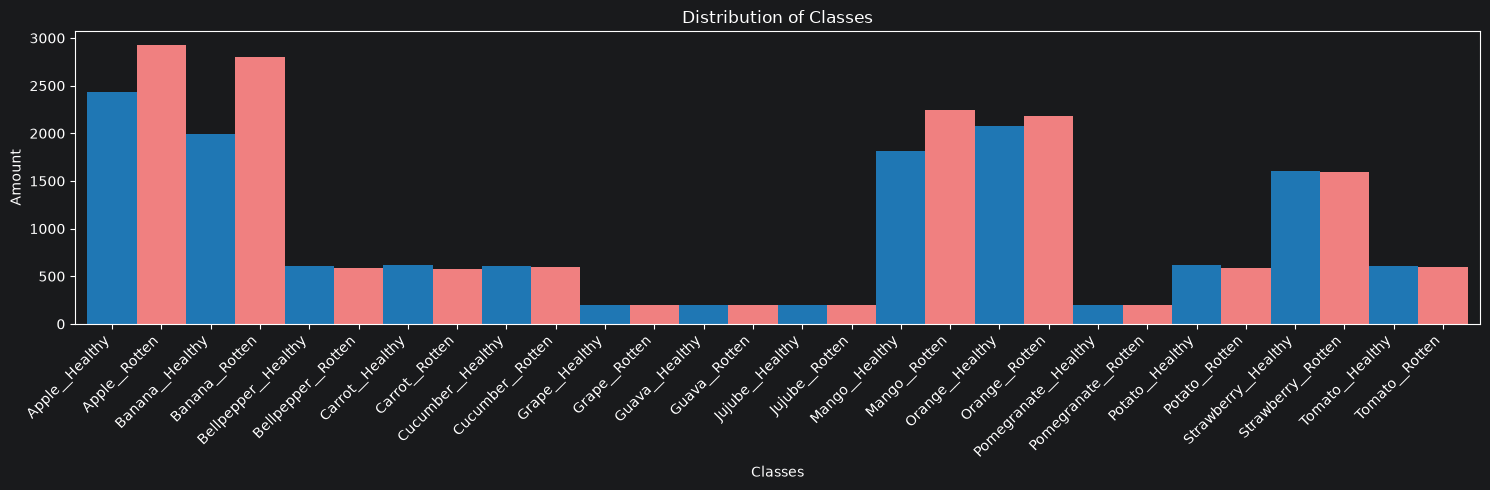

In [14]:
dataset_img_paths = []
dataset_labels = []

# Identify the class names.
dataset_classes = sorted([x for x in os.listdir(DATASET_DIRECTORY) if os.path.isdir(os.path.join(DATASET_DIRECTORY, x))])

# Iterate through files to identify images and labels.
for label, dataset_class in enumerate(dataset_classes):
    directory = os.path.join(DATASET_DIRECTORY, dataset_class) 
    for file_identifier in os.listdir(directory):
        if file_identifier.lower().endswith(('.jpg', '.jpeg', '.png')):
            dataset_img_paths.append(os.path.join(directory, file_identifier))
            dataset_labels.append(label)

# Clean PNG images found in path list (To avoid icc warning each epoch)
for img_path in dataset_img_paths:
    if img_path.lower().endswith('.png'):
        try:
            with Image.open(img_path) as img:
                # If it has an embedded icc_profile, overwrite it to strip it out
                if 'icc_profile' in img.info:
                    img.save(img_path, icc_profile=None)
        except Exception:
            pass # Skip any corrupted images silently

print("Classes loaded: " + str(len(dataset_classes)))
print("Image locations loaded: " + str(len(dataset_img_paths)))
print("Labels loaded: " + str(len(dataset_labels)))

# Create simple table for displaying the total amount of data in each class.
dataset_label_ints = pd.Series(dataset_labels).value_counts().sort_index()
dataset_distribution = pd.DataFrame({
    "Class": dataset_classes,
    "Amount": dataset_label_ints.values
})
ax = dataset_distribution.set_index('Class').plot(
    kind='bar',
    width=1,
    figsize=(15,5),
    legend=False,
)
colours = ["tab:blue", "lightcoral"]
for i, bar in enumerate(ax.patches):
    bar.set_facecolor(colours[i % len(colours)])
plt.xticks(rotation=45, ha="right")
plt.title('Distribution of Classes')
plt.xlabel('Classes')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()

### Split the data into training, validation and testing.

Using an 80/10/10 split of training, validation and testing data.

In [15]:
X_training, X_valTest, y_training, y_valTest = train_test_split(
    dataset_img_paths,
    dataset_labels,
    test_size=0.2,
    random_state=RAN_SEED
)

X_validation, X_testing, y_validation, y_testing = train_test_split(
    X_valTest,
    y_valTest,
    test_size=0.5,
    random_state=RAN_SEED
)

print(
    'Training Data:', str(len(X_training)),
    '\nValidation Data:', str(len(X_validation)),
    '\nTesting Data:', str(len(X_testing))
)

Training Data: 23418 
Validation Data: 2927 
Testing Data: 2928


### Image loading and dataset creation functions

In [16]:
def load_images(dataset_image_path, dataset_image_label):
    dataset_image = tf.io.read_file(dataset_image_path)
    dataset_image = tf.image.decode_image(dataset_image, channels=3, expand_animations=False)
    dataset_image = tf.image.resize(dataset_image, IMAGE_SIZE)
    dataset_image = tf.cast(dataset_image, tf.float32) / 255.0
    return dataset_image, dataset_image_label

def create_tensorflow_dataset(dataset_image_path, dataset_image_label, train):
    tf_dataset = tf.data.Dataset.from_tensor_slices((dataset_image_path, dataset_image_label))
    tf_dataset = tf_dataset.map(load_images, num_parallel_calls=tf.data.AUTOTUNE)
    if train: tf_dataset = tf_dataset.shuffle(1000, RAN_SEED)
    tf_dataset = tf_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return tf_dataset

### Use above functions to instantiate the training, validation and testing datasets.
Also, an optional function to visualise the training data if line 18 uncommented.

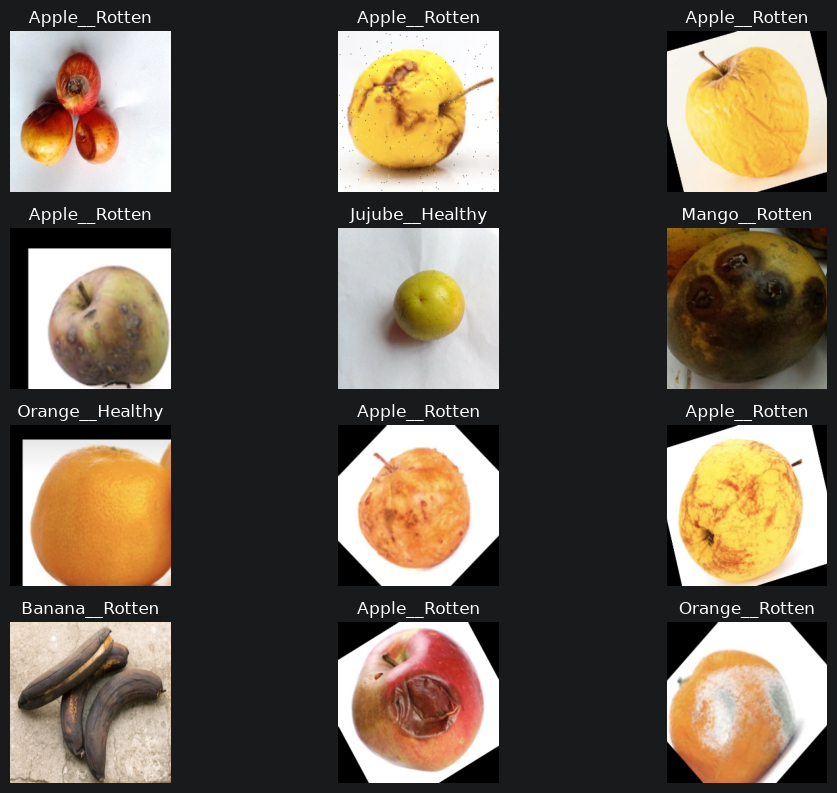

In [17]:
tf_training_dataset = create_tensorflow_dataset(X_training, y_training, True)
tf_validation_dataset = create_tensorflow_dataset(X_validation, y_validation,False)
tf_testing_dataset = create_tensorflow_dataset(X_testing, y_testing, False)

# Visualise training data
def vis_training_data():
    plt.figure(figsize=(10,10))
    for image, d_label in tf_training_dataset.take(1):
        for i in range(12):
            ax = plt.subplot(5, 3, i + 1)
            plt.imshow(image[i].numpy(), cmap='gray')
            plt.title(dataset_classes[d_label[i].numpy()])
            plt.axis('off')
    plt.tight_layout()
    plt.show()

# UNCOMMENT THIS TO RENDER VISUALISATION
vis_training_data()

### Create and Compile Keras Model

In [18]:
dataset_classes_amount = len(dataset_classes)
dataset_model_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomZoom(0.1),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomFlip('horizontal')
    ]
)

dataset_model = models.Sequential(
    [
        layers.Input(shape=(244, 244, 3)),
        dataset_model_augmentation,
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(dataset_classes_amount, activation='softmax')
    ]
)

dataset_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'],)
dataset_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 244, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 244, 244, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 122, 122, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 122, 122, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 30, 30, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    14,745,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 28)             │         7,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,141,468 (57.76 MB)

 Trainable params: 15,141,468 (57.76 MB)

 Non-trainable params: 0 (0.00 B)

### Fit the Model

In [19]:
dataset_model_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, verbose=0, mode='auto', restore_best_weights=True),
    ModelCheckpoint(filepath='../models/fruit_cnn.keras', monitor='val_accuracy', save_best_only=True, mode='auto', verbose=0),
]
cnn_history = dataset_model.fit(tf_training_dataset, validation_data=tf_validation_dataset, epochs=EPOCHS, callbacks=dataset_model_callbacks, shuffle=False)

# Test model using testing data.
cnn_test_loss, cnn_test_accuracy = dataset_model.evaluate(tf_testing_dataset, verbose=0)
print('CNN Testing Data Loss:', cnn_test_loss, ',\nCNN Testing Data Accuracy:', cnn_test_accuracy)


Epoch 1/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 263s 358ms/step - accuracy: 0.4214 - loss: 1.9467 - val_accuracy: 0.5975 - val_loss: 1.3058
Epoch 2/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 262s 357ms/step - accuracy: 0.6265 - loss: 1.2295 - val_accuracy: 0.7516 - val_loss: 0.8143
Epoch 3/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 267s 363ms/step - accuracy: 0.6930 - loss: 1.0002 - val_accuracy: 0.7954 - val_loss: 0.6929
Epoch 4/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 268s 365ms/step - accuracy: 0.7370 - loss: 0.8524 - val_accuracy: 0.8155 - val_loss: 0.6038
Epoch 5/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 269s 366ms/step - accuracy: 0.7703 - loss: 0.7419 - val_accuracy: 0.8538 - val_loss: 0.4755
Epoch 6/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 273s 371ms/step - accuracy: 0.7839 - loss: 0.6878 - val_accuracy: 0.8446 - val_loss: 0.4854
Epoch 7/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 265s 361ms/step - accuracy: 0.8061 - loss: 0.6224 - val_accuracy: 0.8500 - val_loss: 0.4648
Epoch 8/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 277s 377ms/step - accuracy: 0.8243 -

### Display accuracy, loss and classification report of model in a visual format

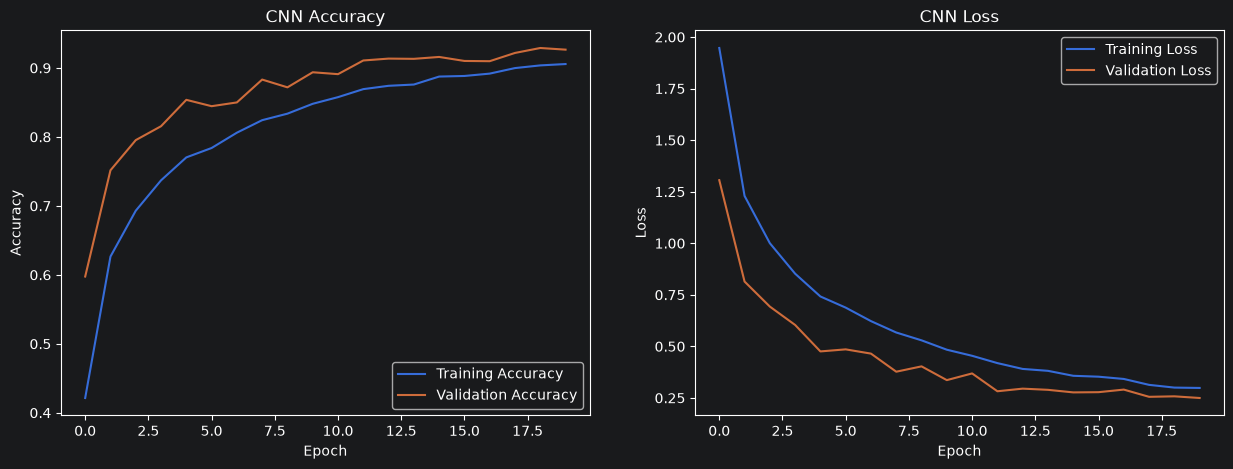

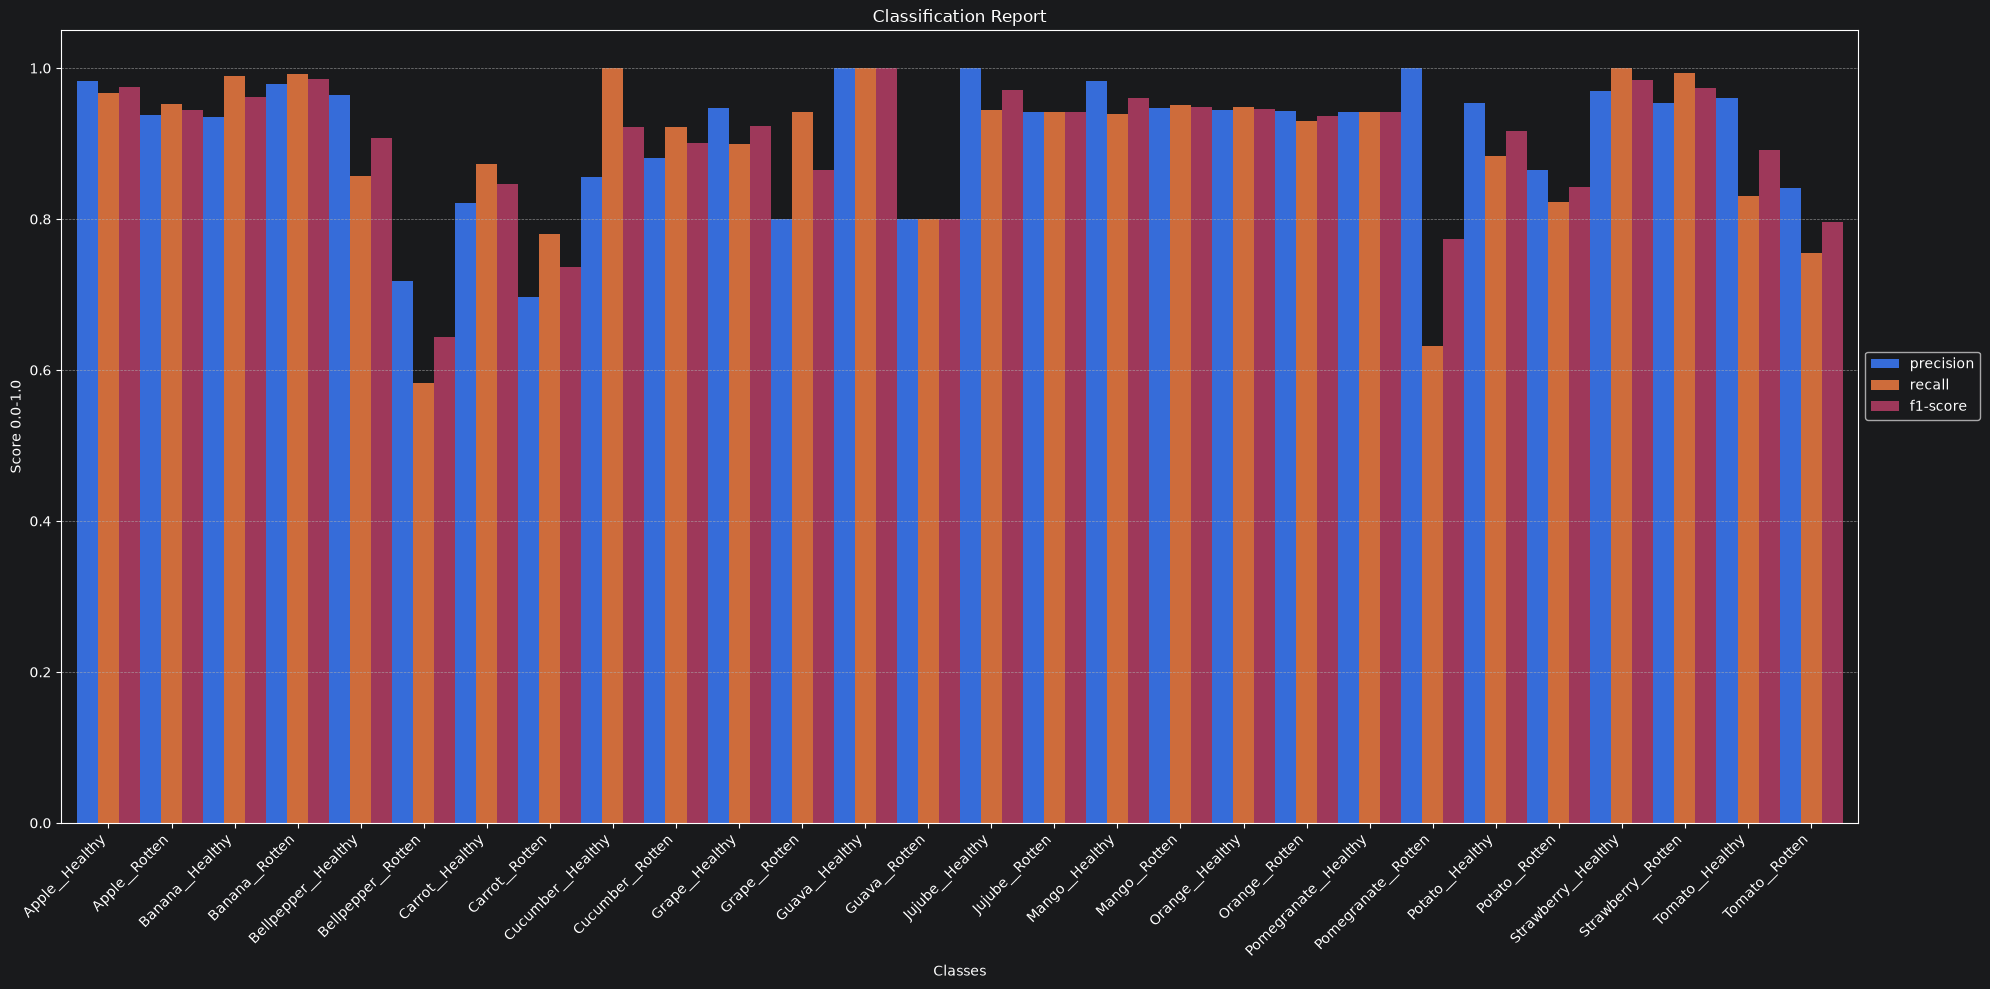

In [20]:
from sklearn.metrics import classification_report

# Get data for classification report.
y_true = []
y_predicted = []
for images, labels_batch in tf_testing_dataset:
    predicted = dataset_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predicted, axis=1)

    y_true.extend(labels_batch.numpy())
    y_predicted.extend(predicted_labels)

# Model accuracy and loss figure
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.plot(cnn_history.history['accuracy'], label="Training Accuracy")
plt.plot(cnn_history.history['val_accuracy'], label="Validation Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(cnn_history.history['loss'], label="Training Loss")
plt.plot(cnn_history.history['val_loss'], label="Validation Loss")
plt.legend()
plt.show()


# Classification report figure.
classification_report_dictionary = classification_report(y_true, y_predicted, target_names=dataset_classes, output_dict=True)
df = pd.DataFrame(classification_report_dictionary).iloc[:-1, :28].T

ax = df.plot(kind='bar', width=1, figsize=(20,10))
plt.title('Classification Report')
plt.xlabel('Classes')
plt.ylabel('Score 0.0-1.0')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

# Save model to dir.
dataset_model.save('../models/trained_fruit_cnn.keras')


### Confusion Matrix

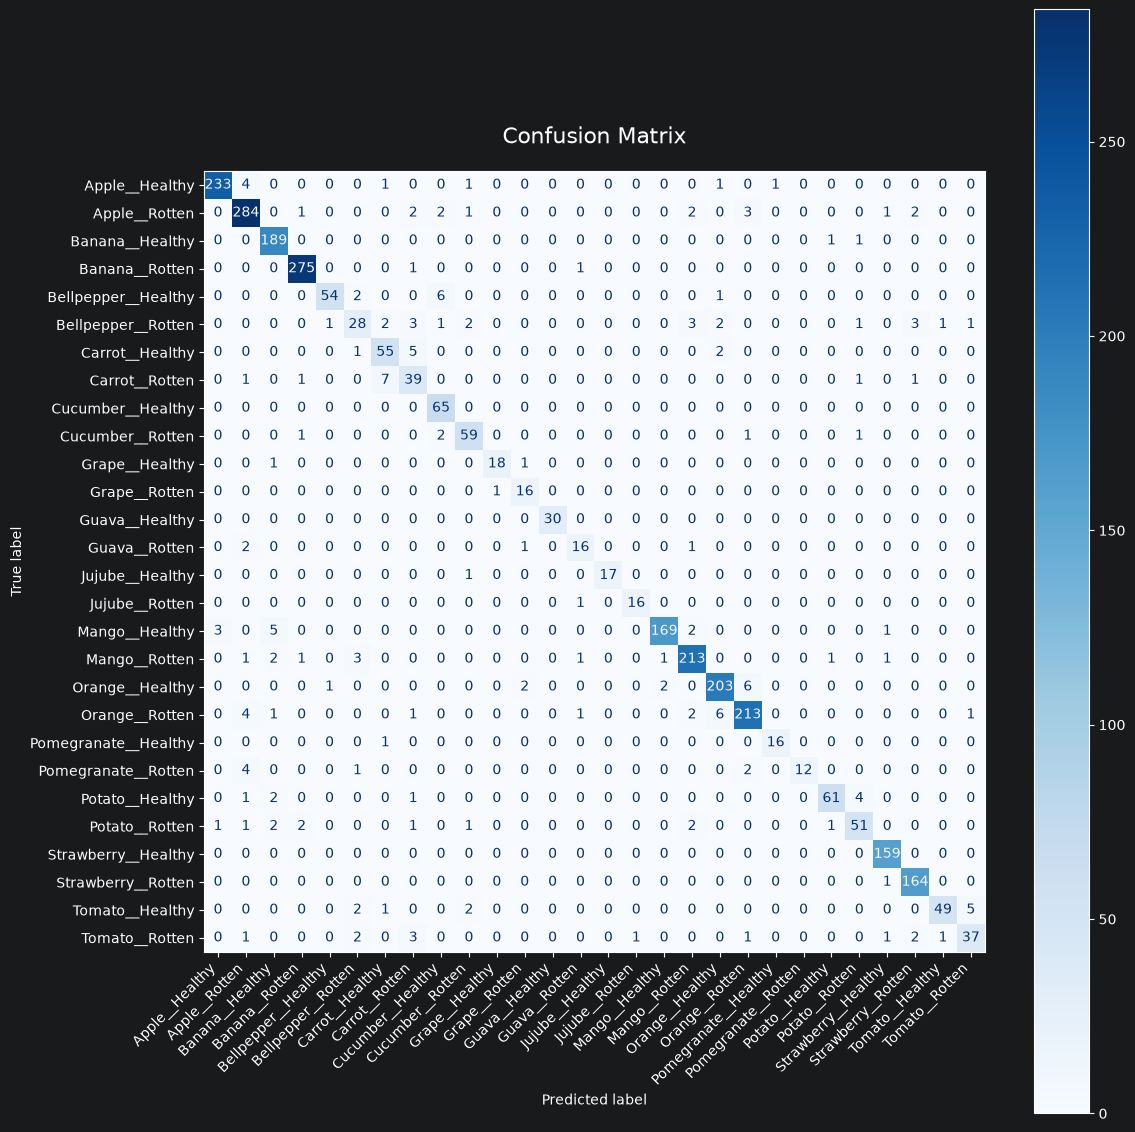

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

conf_matrix = confusion_matrix(y_true, y_predicted)
display = ConfusionMatrixDisplay(conf_matrix, display_labels=dataset_classes)

fig, ax = plt.subplots(figsize=(12,12))
display.plot(cmap="Blues", ax=ax, values_format='d')
plt.title("Confusion Matrix", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()